## Dynamical Low-Rank PCG

This notebook tests out the Dynamical Low-Rank Preconditioned Conjugate Gradient (DLR-PCG), proposed in the thesis, scheme on some simple problems. 

For the implementation, see `src/algorithms/dynamical_low_rank_pcg.py`

---

In [191]:
import matplotlib.pyplot as plt

from fenics import Function, plot
from utils.colors import CMAP
from utils.problem_setup import TestProblemsSetup

import importlib
import algorithms.dynamical_low_rank_pcg
importlib.reload(algorithms.dynamical_low_rank_pcg)
from algorithms.dynamical_low_rank_pcg import DynamicalLowRankPCG

import numpy as np

SEED = 15

Converged at iter 3 [rel_res=1.79e-09]


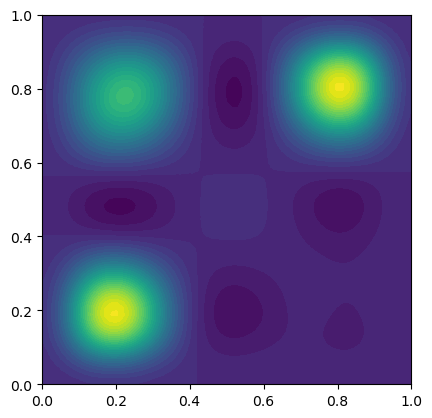

In [200]:
p = problems['II']
solver = DynamicalLowRankPCG(p['rsvd'])

x_hat = solver.solve(
    y=p['y'],
    w=p['w'],
    lambda_=(1e-4)**2,
    max_rank=2,
    preconditioner='ic',
    X0='qr'
)
f_hat = Function(p['V_h'])
f_hat.vector()[:] = x_hat
plot(f_hat)

Converged at iter 3 [rel_res=5.47e-09]
Converged at iter 3 [rel_res=5.6e-09]
Converged at iter 3 [rel_res=5.28e-09]


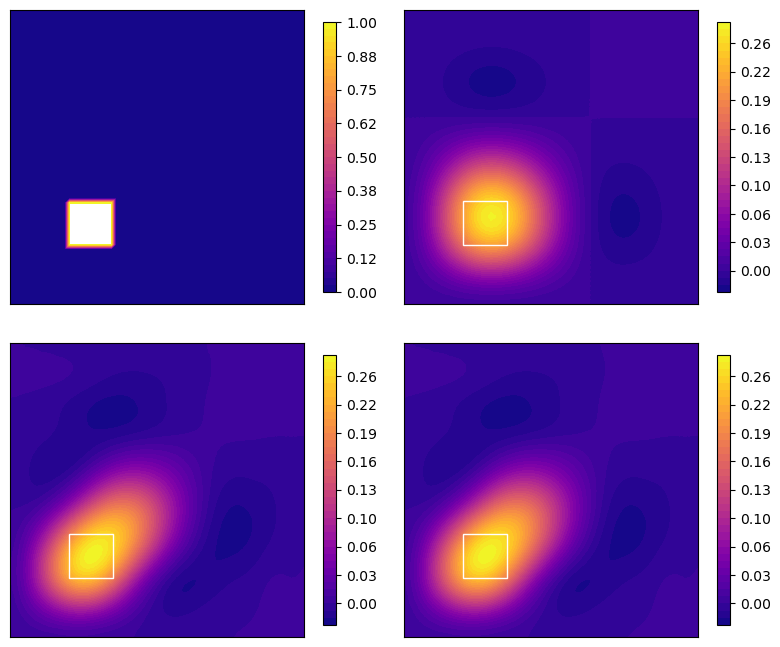

In [18]:
def plot_solutions(f_list, fig_name=None, x0_list=None, y0_list=None, width=0.15, height=0.15):
    import matplotlib.patches as patches
    fig, axes = plt.subplots(2, 2, figsize=(8, 7))
    axes = axes.flatten()

    for i, (ax, fi) in enumerate(zip(axes, f_list)):
        plt.sca(ax)
        p = plot(fi, cmap=CMAP)

        fig.colorbar(p, ax=ax, format="%.2f", shrink=0.8)
        ax.set_xticks([])
        ax.set_yticks([])
 
        # Plot square
        if i != 0 and x0_list is not None:
            for x0, y0 in zip(x0_list, y0_list):
                square = patches.Rectangle((x0, y0), width, height, edgecolor='white', facecolor='none')
                ax.add_patch(square)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.07)
    if fig_name is not None:
        plt.savefig(f'../figures/{fig_name}', dpi=300, bbox_inches='tight')
    plt.show()

    plt.show()

p = problems['I']
solver = DynamicalLowRankPCG(p['rsvd'])

f_list = [p['f']]
for mr in [1, 2, 15]:
    x_hat = solver.solve(
        y=p['y'],
        w=p['w'],
        lambda_=(1e-4)**2,
        max_rank=mr,
        preconditioner='ic',
        truncate_tol=0.1
    )
    f_hat = Function(p['V_h'])
    f_hat.vector()[:] = x_hat
    f_list.append(f_hat)


x0_list, y0_list = [0.2], [0.2]
plot_solutions(f_list, x0_list=x0_list, y0_list=y0_list)

---

Converged at iter 196 [rel_res=8.46e-09]
Converged at iter 190 [rel_res=8.83e-09]
Converged at iter 186 [rel_res=7.51e-09]


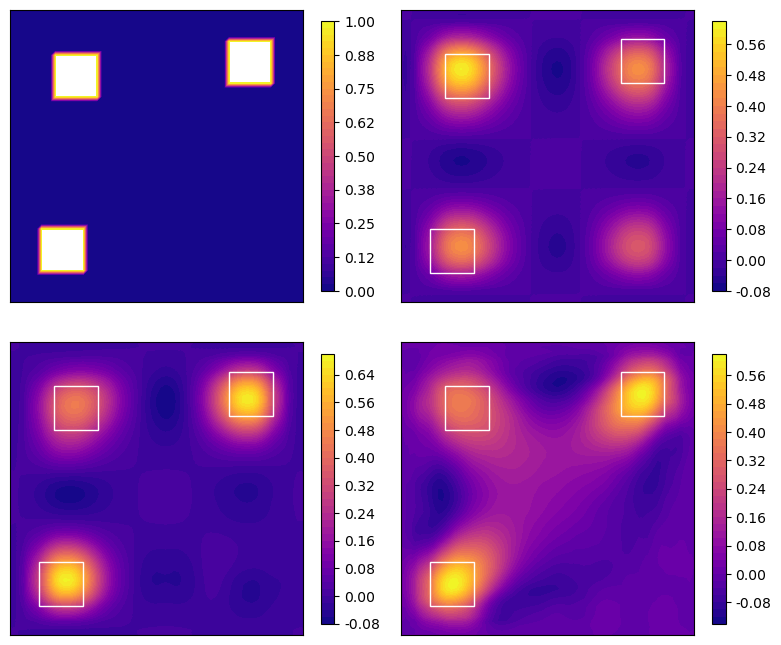

In [4]:
p = problems['II']
solver = DynamicalLowRankCG(p['rsvd'])

f_list = [p['f']]
for mr in [1, 2, 15]:
    x_hat = solver.solve(
        y=p['y'],
        w=p['w'],
        lambda_=(1e-4)**2,
        max_rank=mr,
    )
    f_hat = Function(p['V_h'])
    f_hat.vector()[:] = x_hat
    f_list.append(f_hat)

x0_list, y0_list = [0.1, 0.75, 0.15], [0.1, 0.75, 0.70]
plot_solutions(f_list, x0_list=x0_list, y0_list=y0_list)